# Simulation of emittance measurement

In [ ]:
import RF_Track as rft 
import numpy as np 
import scipy
import matplotlib.pyplot as plt 

# Bunch parameters

In [ ]:
# Bunch parameters
mass = rft.electronmass # MeV / c^2
charge=-1 # single particle charge, in units of e
population = 1 * rft.nC # number of real particles per bunch
Pref = 5 # reference momentum, MeV / c
P_Q = Pref / charge # MV / c, reference rigidity

# Creating an essential beam line

In [ ]:
Lcell=2 # m
Lquad=0.2 # m
Ldrift=Lcell/2-Lquad # m

mu = np.deg2rad(90) # deg
K1L=np.sin(mu/2) / (Lcell/4) # 1/m

strength=K1L * P_Q # MeV / m

# A full, focusing quadrupole
Q=rft.Quadrupole(Lquad,strength)

# The Drift
Dr = rft.Drift(Ldrift)
Dr.set_tt_nsteps(100)

# The Screen

S = rft.Screen()

# Defining the sequence

Beamline=rft.Lattice()
Beamline.append(Q)
Beamline.append(Dr)
Beamline.append(S)

# Creating a bunch and specifying the Twiss parameters and emittance

In [ ]:
Twiss=rft.Bunch6d_twiss()
Twiss.beta_x = Lcell * (1 + np.sin(mu/2)) / np.sin(mu); # m
Twiss.beta_y = Lcell * (1 - np.sin(mu/2)) / np.sin(mu); # m
Twiss.alpha_x = 0.0
Twiss.alpha_y = 0.0
Twiss.emitt_x = 1; # mm.mrad, normalized emittances
Twiss.emitt_y = 1; # mm.mrad

N = 10000
B0 = rft.Bunch6d(mass, population, charge, Pref, Twiss, N)

# Track the bunch through the lattice

Beamline.track(B0)


<RF_Track.Bunch6d; proxy of <Swig Object of type 'Bunch6d *' at 0x7f6511564230> >

# Calculating beam sizes and getting transport table

In [ ]:

T = Beamline.get_transport_table('%S %sigma_x %sigma_y %sigma_t %sigma_E %mean_E %emitt_x %emitt_y %beta_x %beta_y')

B=Beamline.get_bunch_at_screens()

M=B[0].get_phase_space('%x %y')
x,y=M[:,0],M[:,1]

# Calculate beam sizes

sigma_x= np.sqrt(np.mean((x-np.mean(x))**2)) 
sigma_y= np.sqrt(np.mean((y-np.mean(y))**2))

print("Beam sizes for nominal quadrupol settings are: ")
print(f"Sigma x: {sigma_x} mm")
print(f"Sigma y: {sigma_y} mm")

Beam sizes for nominal quadrupol settings are: 
Sigma x: 0.1984227589232481 mm
Sigma y: 0.7445937182125999 mm


# Performing quadrupole scan by varying its strength and fitting the parameters

#### epsilon  11 = A(K-B)^2+C, so y=a(x-p)^2+q where A=a, B=-b/2a , C= c-b^2/4a

In [ ]:
K1L_values=np.linspace(K1L*0.5,K1L*1.5,15)
sigma_x2_values,sigma_y2_values = [], []

for K1L_value in K1L_values:
    Beamline[0].set_K1L(abs(P_Q), K1L_value)
    Beamline.track(B0)
    M = Beamline.get_bunch_at_screens()[0].get_phase_space('%x %y')
    x,y = M[:,0], M[:,1]
    sigma_x2_values.append(np.var(x)) # mm^2
    sigma_y2_values.append(np.var(y)) # mm^2

# Fitting a parabola in plane u (x or y)

a_x,b_x,c_x=np.polyfit(K1L_values,sigma_x2_values,2)
A_x = a_x
B_x = -b_x/(2*a_x)
C_x = c_x-(b_x*b_x/(4*a_x))

a_y,b_y,c_y=np.polyfit(K1L_values,sigma_y2_values,2)
A_y = a_y
B_y = -b_y/(2*a_y)
C_y = c_y-(b_y*b_y/(4*a_y))

print("Plane x: ")
print(f"A = {A_x} ")
print(f"B = {B_x} ")
print(f"C = {C_x}")

print("Plane y: ")
print(f"A = {A_y} ")
print(f"B = {B_y} ")
print(f"C = {C_y}")

Plane x: 
A = 0.3922334805179403 
B = -0.677012034391393 
C = 0.2536261194404154
Plane y: 
A = 0.041457793074595385 
B = 1.5063962723472082 
C = 0.13768874347294252


The total transfer matrix of interest here is R = SQ, where S denotes the known transfer matrix between the quadrupole and the wire, and Q is the transfer matrix of the quadrupole:
\begin{equation*}
\\Q = \left(\begin{array}{rl}
\mathbf{1}&\mathbf{0}\\
\mathbf{K} & \mathbf{1}\\
\end{array}\right),
\end{equation*}

With 
\begin{equation*}
\\S = R_{drift} = \left(\begin{array}{rl}
\mathbf{1}&\mathbf{L}\\
\mathbf{0} & \mathbf{1}\\
\end{array}\right),
\end{equation*}

Which gives us:



# Simulation of emittance measurement

In [ ]:
L = 0.5 * Lquad + Ldrift
sigma_x_11 = A_x / (L**2)
sigma_x_12 = (-A_x/(L**2)) * (B_x + 1 / L)
sigma_x_22 = (1 / (L**2)) * (( A_x * (B_x**2) + C_x) + 2 * A_x * B_x* (1 / L) + A_x * (1 / L)**2)

sigma_y_11 = A_y / (L**2)
sigma_y_12 = (-A_y/(L**2)) * (B_y + 1 / L)
sigma_y_22 = (1 / (L**2)) * (( A_y * (B_y**2) + C_y) + 2 * A_y * B_y* (1 / L) + A_y * (1 / L)**2)


The beam emittance is then calculated from the determinant of the beam matrix x = √det Σx beam and the errors are propagated:


In [ ]:
det_sigma_x_beam = sigma_x_11 * sigma_x_22 - sigma_x_12**2
det_sigma_y_beam = sigma_y_11 * sigma_y_22 - sigma_y_12**2

emittance_x = np.sqrt(det_sigma_x_beam)
emittance_y = np.sqrt(det_sigma_y_beam)
print(f"Emittance in the plane x: {emittance_x} mm.rad")
print(f"Emittance in the plane y: {emittance_y} mm.rad")

# Alternative way
# det_sigma_x_beam = A_x * C_x  / (L**4)
# det_sigma_y_beam = A_x * C_x  / (L**4)

# emittance_x = np.sqrt(A_y * C_y) / (L**2)
# emittance_y = np.sqrt(A_y * C_y) / (L**2)

Emittance in the plane x: 0.3893895573476466 mm.rad
Emittance in the plane y: 0.09327543631452571 mm.rad


magnetic rigidity integral

In [ ]:
# Magnetic rigidity of the beam
B_rho = 3.356 * Pref # T * m

# Change in the quadrupole field
G_ds = B_rho * (K1L_values - K1L)



Text(0, 0.5, 'sigma_x**2')

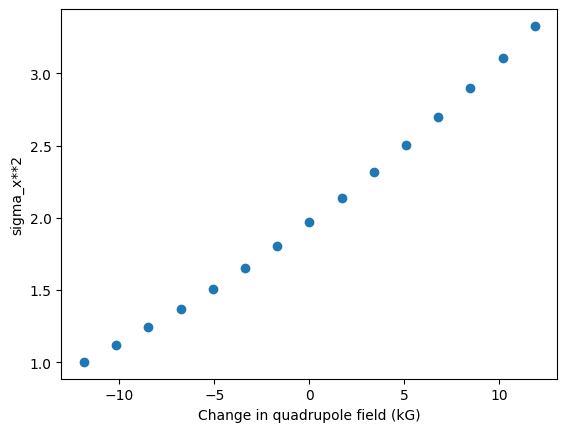

In [ ]:
plt.figure()
plt.plot(G_ds,np.array(sigma_x2_values),'o')
plt.xlabel("Change in quadrupole field (kG)")
plt.ylabel("sigma_x**2")